# Tabular TD(0) for estimating $v_\pi$ — How Bootstrapping Tames MC's Variance

### In-Class Exercise #2 (19 Jun) · Reinforcement Learning

In **Exercise #1** we watched Monte Carlo (MC) off-policy importance sampling produce a *variance monster*: estimates that bounced around wildly and refused to settle even after a million episodes. We ended with a cliff-hanger — *"is there a method that doesn't blow up like this?"*

**This notebook is the answer: Temporal-Difference learning, TD(0).**

We study the Sutton & Barto pseudocode below, turn it into running Python, and then spend most of our energy on the exercise's key ask:

> *Show how the algorithm **mitigates the large variances** observed in MC.*

```
Tabular TD(0) for estimating v_pi
Input: the policy π to be evaluated
Algorithm parameter: step size α ∈ (0, 1]
Initialize V(s), for all s ∈ S⁺, arbitrarily except that V(terminal) = 0
Loop for each episode:
    Initialize S
    Loop for each step of episode:
        A ← action given by π for S
        Take action A, observe R, S'
        V(S) ← V(S) + α[ R + γ·V(S') − V(S) ]
        S ← S'
    until S is terminal
```

## What You'll Learn

1. What **bootstrapping** means, and why it is the single idea that separates TD from MC.
2. How to read and run the **Tabular TD(0)** pseudocode line by line.
3. What the **TD target** `R + γV(S')` and **TD error** `δ` (delta) are, in plain English.
4. Why MC updates toward the *whole noisy return* `G`, while TD updates toward a *low-variance* one-step target — and why that **cuts the variance dramatically**.
5. The honest **bias–variance trade-off**: TD trades a little bias for much lower variance (the mirror image of weighted importance sampling from Exercise #1).
6. **The big one:** graphs that put MC's variance and TD's calm side by side.

## Key Vocabulary

| Term | Simple Explanation |
|------|--------------------|
| **Prediction (policy evaluation)** | Estimating how good a *fixed* policy `π` is — its value `v_π(s)` for each state. (Not finding the best policy; that's control.) |
| **`V(s)`** | Our current estimate of the value of being in state `s` under policy `π`. |
| **Return `G`** | The *actual* total reward collected from a state until the episode ends. What MC averages. |
| **Bootstrapping** | Updating an estimate using *another estimate* instead of waiting for the final answer. "Standing on your own shoulders." |
| **TD target** | `R + γV(S')` — one real reward plus our current guess of the next state's value. The thing TD nudges toward. |
| **TD error `δ` (delta)** | `δ = R + γV(S') − V(S)` — the surprise: how wrong our old estimate was, compared to the one-step target. |
| **Step size `α` (alpha)** | How big a nudge each update makes, `0 < α ≤ 1`. Like a learning rate. |
| **Bias** | A *systematic* offset — being consistently a bit off-target. |
| **Variance** | How wildly an estimate bounces around from run to run. High variance = untrustworthy. |
| **Bootstrapped vs. sampled** | TD's target is *part estimate* (bootstrapped); MC's target is *fully sampled* (the real return). |

### Setup

We import our tools and pin the random seed so the lecture is reproducible — *run it again, get the same picture.*

In [1]:
# --- Standard data-science toolkit ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings so the lecture output stays clean and readable
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# seed = 42 so every run of this notebook looks identical.
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

print("Toolkit ready. NumPy", np.__version__)

Toolkit ready. NumPy 2.4.6


---
# Part 1 — The Big Idea: Bootstrapping (Sutton's "Driving Home" analogy)

Imagine you're driving home and you keep a running guess of **"minutes left until I'm home."**

- **Monte Carlo (MC) way:** Don't change any guess until you *actually arrive*. Only then do you look back and correct every guess using the **true** total time. Accurate in the end — but you learn nothing until the trip is over, and your correction depends on *everything* that happened (a deer on the road, a traffic jam, a green-light streak). That whole-trip randomness is **high variance**.

- **TD(0) way:** At **every checkpoint**, update your guess using the *next* checkpoint's guess. "I thought 30 minutes from the office exit. I reached the highway 5 minutes later and from here I usually think it's 20 more. So my office-exit guess should have been ~25, not 30." You **don't wait for the ending** — you lean on your *current estimate* of what's left. That's **bootstrapping**.

The TD update in one line:

$$V(S) \;\leftarrow\; V(S) + \alpha\big[\underbrace{R + \gamma V(S')}_{\text{TD target}} - V(S)\big], \qquad \delta = R + \gamma V(S') - V(S)$$

**Why this matters for variance:** MC's target is the full return `G`, which soaks up the randomness of the *entire rest of the episode*. TD's target is `R + γV(S')` — just **one** random reward and step, plus a (relatively stable) estimate. One coin-flip's worth of noise instead of a hundred. **That is the variance mitigation**, and the rest of this notebook makes it visible.

---
# Part 2 — The Test Bed: the 5-State Random Walk (Sutton & Barto, Example 6.2)

To *measure* variance we need a world where we know the true answer. The classic choice:

```
   [ T ] -- A -- B -- C -- D -- E -- [ T ]
   left                                right
  terminal                          terminal
   (0)                                (+1)
```

- Five non-terminal states **A B C D E**. Every episode **starts in the middle, C**.
- Each step, the policy `π` flips a fair coin: move **left** or **right** with probability 0.5 (this is the policy we are evaluating).
- All rewards are **0**, except stepping into the **right** terminal gives **+1**. `γ = 1`.

Because it's a symmetric random walk, the true value of each state is just its **probability of eventually reaching the right end**:

$$v_\pi(A,B,C,D,E) = \tfrac{1}{6},\,\tfrac{2}{6},\,\tfrac{3}{6},\,\tfrac{4}{6},\,\tfrac{5}{6}$$

Those exact numbers are our **bullseye** — every estimate is trying to hit them, and "how noisy is the estimate" is now something we can plot.

In [2]:
# State encoding: 0 = left terminal, 1..5 = A,B,C,D,E, 6 = right terminal
STATE_NAMES = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E'}
NONTERMINAL = [1, 2, 3, 4, 5]
START_STATE = 3                              # always start at C
TRUE_VALUES = np.array([1, 2, 3, 4, 5]) / 6.0   # true v_pi for A..E

def random_walk_step(state, rng):
    """Take one step of the random-walk policy (50/50 left/right).
    Returns (next_state, reward, done)."""
    move = -1 if rng.random() < 0.5 else +1
    next_state = state + move
    if next_state == 6:          # entered the RIGHT terminal
        return next_state, 1.0, True
    if next_state == 0:          # entered the LEFT terminal
        return next_state, 0.0, True
    return next_state, 0.0, False

# Sanity check: generate one episode and print the path
demo_rng = np.random.default_rng(0)
s, path = START_STATE, ['C']
while True:
    s, r, done = random_walk_step(s, demo_rng)
    path.append(STATE_NAMES.get(s, 'T'))
    if done:
        break
print("One sample walk:", " -> ".join(path), f"   (final reward = {r})")
print("True values  A..E:", np.round(TRUE_VALUES, 3))

One sample walk: C -> D -> C -> B -> A -> B -> C -> D -> E -> T    (final reward = 1.0)
True values  A..E: [0.167 0.333 0.5   0.667 0.833]


### Implement TD(0) *with a key-variable trace*

The exercise asks us to **run the pseudocode** and to **show how it mitigates variance**. First, the faithful implementation — with an optional trace that prints the variables named in the pseudocode at every step: the **TD target** `R + γV(S')`, the **TD error** `δ`, and `V(S)` before and after.

In [3]:
def td0_prediction(num_episodes, alpha=0.1, gamma=1.0, seed=0,
                   record_state=START_STATE, trace=False):
    """Tabular TD(0) for estimating v_pi on the random walk, faithful to the pseudocode.

    Returns:
      V        : final value estimates (array indexed by state 0..6)
      history  : V(record_state) after each episode (to plot learning)
    If trace=True, narrates the key variables for the FIRST episode.
    """
    rng = np.random.default_rng(seed)

    # Initialize V arbitrarily EXCEPT terminals = 0.  The textbook uses 0.5 for
    # the non-terminal states (a neutral starting guess).
    V = np.zeros(7)
    for s in NONTERMINAL:
        V[s] = 0.5

    history = []
    for ep in range(num_episodes):
        S = START_STATE                       # Initialize S
        do_trace = trace and ep == 0
        if do_trace:
            print("=== Tracing TD(0) episode 0 ===")
            print(f"  start V = {[round(V[s],3) for s in NONTERMINAL]} (states A..E)\n")

        while True:                            # Loop for each step of episode
            # A <- action given by pi for S; Take action A, observe R, S'
            S_next, R, done = random_walk_step(S, rng)

            td_target = R + gamma * V[S_next]  # the bootstrapped target
            td_error  = td_target - V[S]       # delta = R + gamma*V(S') - V(S)
            V_old = V[S]
            V[S] = V[S] + alpha * td_error     # the TD(0) update

            if do_trace:
                print(f"  S={STATE_NAMES.get(S,'T')} R={R:.0f} S'={STATE_NAMES.get(S_next,'T')} | "
                      f"target=R+gV(S')={td_target:6.3f}  delta={td_error:+6.3f}  "
                      f"V(S): {V_old:.3f} -> {V[S]:.3f}")

            S = S_next                          # S <- S'
            if done:
                break                           # until S is terminal

        history.append(V[record_state])

    return V, np.array(history)

# Trace one episode so the key variables are visible
V_demo, _ = td0_prediction(num_episodes=1, alpha=0.1, seed=1, trace=True)

=== Tracing TD(0) episode 0 ===
  start V = [np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5)] (states A..E)

  S=C R=0 S'=D | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=D R=0 S'=E | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=E R=0 S'=D | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=D R=0 S'=E | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=E R=0 S'=D | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=D R=0 S'=C | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=C R=0 S'=D | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=D R=0 S'=C | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=C R=0 S'=D | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=D R=0 S'=C | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=C R=0 S'=D | target=R+gV(S')= 0.500  delta=+0.000  V(S): 0.500 -> 0.500
  S=D R=0 S'=E | ta

**Key Insight — what the trace shows:**

- At every step we form the **TD target** `R + γV(S')` and the **TD error** `δ`, then nudge `V(S)` a fraction `α` of the way toward the target.
- Most steps have `R = 0`, so the target is *purely a neighbouring estimate* — that's bootstrapping in action. We learn **mid-episode**, not just at the end.
- The update touches only **one** state per step and depends on only **one** random transition — the seed of TD's low variance.

---
# Part 3 — Does it actually work? TD(0) converges to the true values

Let's run TD(0) for a few hundred episodes and watch the estimates for A–E climb toward `1/6 … 5/6`.

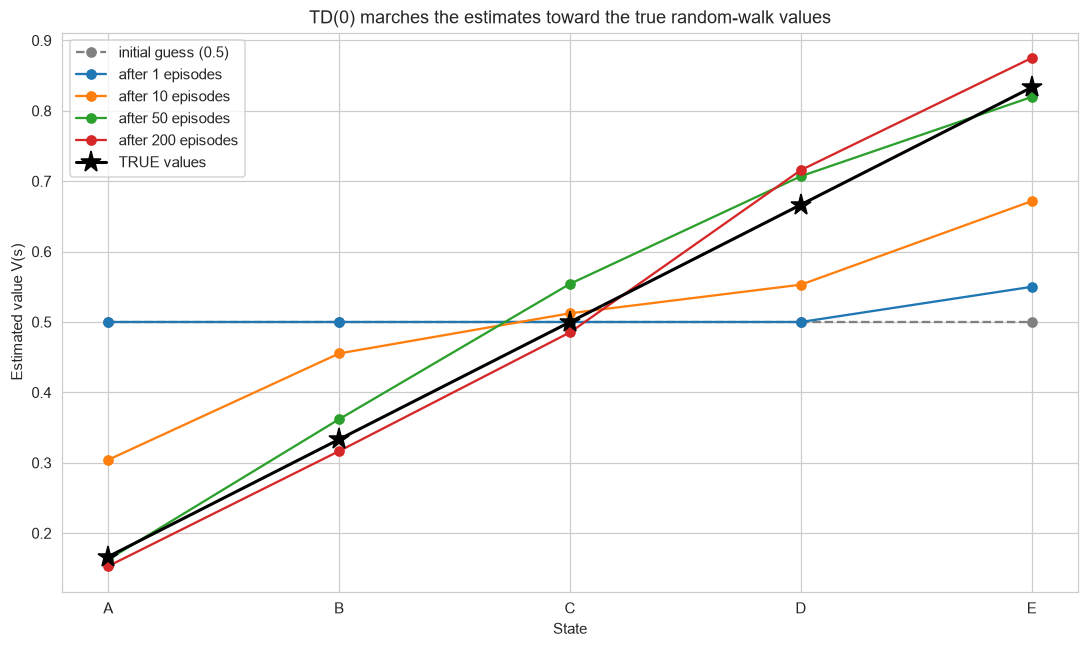

In [4]:
# Train and snapshot the value estimates at a few episode counts
def run_td_snapshots(checkpoints, alpha=0.1, gamma=1.0, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    V = np.zeros(7); V[NONTERMINAL] = 0.5
    snaps = {}
    n = max(checkpoints)
    for ep in range(1, n + 1):
        S = START_STATE
        while True:
            S_next, R, done = random_walk_step(S, rng)
            V[S] += alpha * (R + gamma * V[S_next] - V[S])
            S = S_next
            if done:
                break
        if ep in checkpoints:
            snaps[ep] = V[NONTERMINAL].copy()
    return snaps

checkpoints = [1, 10, 50, 200]
snaps = run_td_snapshots(checkpoints, alpha=0.1)

plt.figure(figsize=(10, 6))
x = NONTERMINAL
plt.plot(x, [0.5]*5, 'o--', color='gray', label='initial guess (0.5)')
for ep in checkpoints:
    plt.plot(x, snaps[ep], 'o-', label=f'after {ep} episodes')
plt.plot(x, TRUE_VALUES, 'k*-', ms=14, lw=2, label='TRUE values')
plt.xticks(x, [STATE_NAMES[s] for s in x])
plt.xlabel('State'); plt.ylabel('Estimated value V(s)')
plt.title('TD(0) marches the estimates toward the true random-walk values')
plt.legend()
plt.tight_layout()
plt.show()

**What do we see here?**

- The flat grey line (everything guessed at 0.5) bends, episode by episode, into the true straight-line shape `1/6 … 5/6`.
- After ~200 episodes the estimates sit close to the bullseye. TD(0) *works* as a prediction method.
- Now the real question: it works — but is it **calmer** than MC? On to the variance show.

---
# Part 4 — The Variance Show: TD vs Monte Carlo

To compare fairly we add a **constant-α Monte Carlo** baseline solving the *same* prediction task. MC waits until the episode ends, computes the real return `G`, and nudges every visited state toward it:

$$V(S) \leftarrow V(S) + \alpha\big[G - V(S)\big]$$

Same world, same α-style update — the **only** difference is the target: MC uses the *full sampled return* `G`; TD uses the *bootstrapped* `R + γV(S')`.

In [5]:
def mc_prediction(num_episodes, alpha=0.1, gamma=1.0, seed=0, record_state=START_STATE):
    """Constant-alpha every-visit Monte Carlo prediction on the random walk.
    Same task as TD(0); the target is the FULL return G instead of a bootstrap."""
    rng = np.random.default_rng(seed)
    V = np.zeros(7); V[NONTERMINAL] = 0.5
    history = []
    for ep in range(num_episodes):
        # Generate a full episode, remembering the states visited
        S = START_STATE
        visited = []
        while True:
            visited.append(S)
            S_next, R, done = random_walk_step(S, rng)
            S = S_next
            if done:
                break
        # With gamma=1 and reward only at the end, the return for EVERY visited
        # state equals the final reward R (0 or 1) -- that 0/1 swing is MC's variance.
        G = R
        for S_visited in visited:
            V[S_visited] += alpha * (G - V[S_visited])
        history.append(V[record_state])
    return V, np.array(history)

# quick check both land near the truth for the middle state C (true value 0.5)
Vtd, _ = td0_prediction(2000, alpha=0.05, seed=1)
Vmc, _ = mc_prediction(2000, alpha=0.02, seed=1)
print(f"True V(C) = 0.5")
print(f"TD(0) estimate of V(C): {Vtd[START_STATE]:.4f}")
print(f"MC    estimate of V(C): {Vmc[START_STATE]:.4f}")

True V(C) = 0.5
TD(0) estimate of V(C): 0.4471
MC    estimate of V(C): 0.4759


### Graph A — The mechanism: MC's target is a coin flip, TD's target is a whisper

Before plotting learning curves, let's look at the **one thing that differs**: the update target for the middle state **C** (true value 0.5).

- **MC return `G` from C:** with `γ=1` and reward only at the right end, the return is `1` if this episode eventually exits right, else `0`. A **0/1 coin flip** — variance ≈ 0.25.
- **TD target `R + γV(S')` from C:** one step to B or D, then their current value. Using the true neighbour values that's `V(B)=2/6` or `V(D)=4/6` — a gentle wobble around 0.5, variance ≈ 0.028.

Both have the **same mean** (0.5, both unbiased here) but wildly different spread. That gap *is* the variance mitigation.

Target for V(C), true value = 0.5
  MC return  G        : mean=0.503  std=0.500  var=0.250
  TD target R+gV(S')  : mean=0.498  std=0.167  var=0.028
  --> TD target variance is ~9x smaller


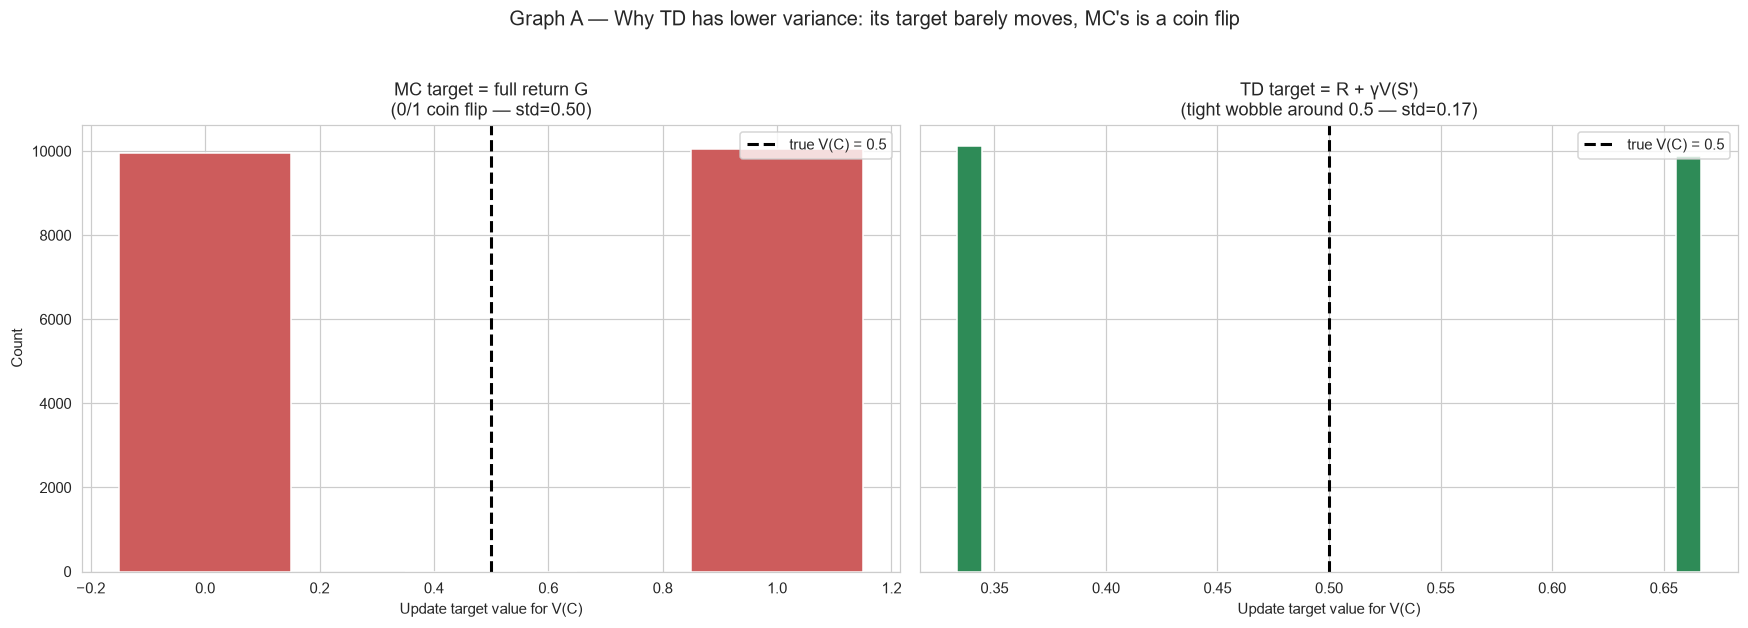

In [6]:
rng = np.random.default_rng(GLOBAL_SEED)
N = 20000

# MC returns observed from state C (full-episode 0/1 outcomes)
mc_targets = []
for _ in range(N):
    S = START_STATE
    while True:
        S, R, done = random_walk_step(S, rng)
        if done:
            break
    mc_targets.append(R)                      # G from C = final reward
mc_targets = np.array(mc_targets)

# TD targets from state C: one step, then the TRUE neighbour value (R is 0 here)
td_targets = []
for _ in range(N):
    S_next, R, done = random_walk_step(START_STATE, rng)
    v_next = 0.0 if S_next in (0, 6) else TRUE_VALUES[S_next - 1]
    td_targets.append(R + v_next)
td_targets = np.array(td_targets)

print(f"Target for V(C), true value = 0.5")
print(f"  MC return  G        : mean={mc_targets.mean():.3f}  std={mc_targets.std():.3f}  var={mc_targets.var():.3f}")
print(f"  TD target R+gV(S')  : mean={td_targets.mean():.3f}  std={td_targets.std():.3f}  var={td_targets.var():.3f}")
print(f"  --> TD target variance is ~{mc_targets.var()/td_targets.var():.0f}x smaller")

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
ax[0].hist(mc_targets, bins=[-0.25,0.25,0.75,1.25], color='indianred', edgecolor='white', rwidth=0.6)
ax[0].set_title(f'MC target = full return G\n(0/1 coin flip — std={mc_targets.std():.2f})')
ax[0].set_xlabel('Update target value for V(C)')
ax[0].set_ylabel('Count')

ax[1].hist(td_targets, bins=30, color='seagreen', edgecolor='white')
ax[1].set_title(f"TD target = R + γV(S')\n(tight wobble around 0.5 — std={td_targets.std():.2f})")
ax[1].set_xlabel('Update target value for V(C)')

for a in ax:
    a.axvline(0.5, color='black', ls='--', lw=2, label='true V(C) = 0.5')
    a.legend()
plt.suptitle("Graph A — Why TD has lower variance: its target barely moves, MC's is a coin flip", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

**Key Insight:**

- **Left (MC):** every update yanks `V(C)` toward `0` or `1` — a violent ±0.5 tug each time. Only *averaging many* of these cancels the noise.
- **Right (TD):** every update nudges `V(C)` toward something already *near* 0.5. Far less to average away.
- Same destination, but TD takes small confident steps while MC takes huge random lurches. Multiply this over thousands of updates and you get the learning curves below.

### Graph B — Learning curves: RMS error vs episodes (mirrors S&B Figure 6.2)

For each method we measure the **root-mean-square (RMS) error** between the estimates and the true values, averaged over all five states and over **100 independent runs**. Lower and smoother = better.

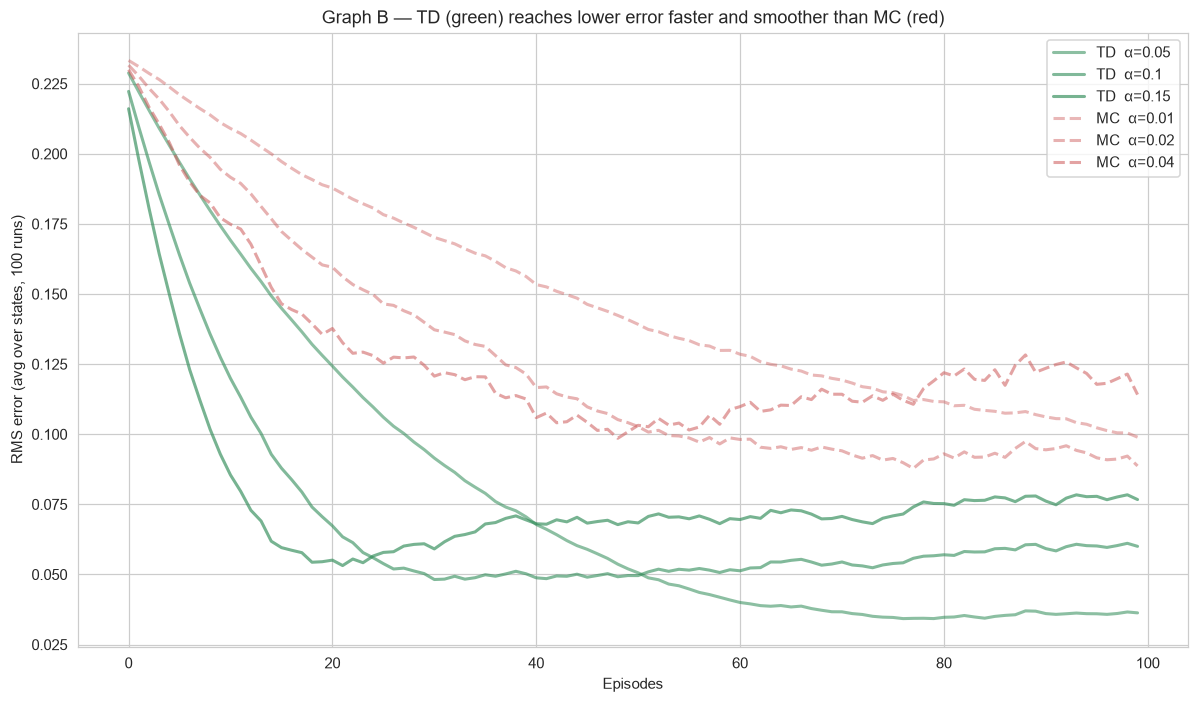

In [7]:
def rms_error(V):
    return np.sqrt(np.mean((V[NONTERMINAL] - TRUE_VALUES) ** 2))

def learning_curve(method, alpha, num_episodes=100, num_runs=100):
    """Average RMS-error-vs-episode curve over many runs for TD or MC."""
    curves = np.zeros((num_runs, num_episodes))
    for run in range(num_runs):
        rng = np.random.default_rng(10_000 + run)
        V = np.zeros(7); V[NONTERMINAL] = 0.5
        for ep in range(num_episodes):
            S = START_STATE
            visited = []
            while True:
                visited.append(S)
                S_next, R, done = random_walk_step(S, rng)
                if method == 'TD':
                    V[S] += alpha * (R + V[S_next] - V[S])
                S = S_next
                if done:
                    break
            if method == 'MC':
                G = R
                for s in visited:
                    V[s] += alpha * (G - V[s])
            curves[run, ep] = rms_error(V)
    return curves.mean(axis=0)

episodes = 100
plt.figure(figsize=(11, 6.5))
for a in [0.05, 0.10, 0.15]:
    plt.plot(learning_curve('TD', a, episodes), color='seagreen',
             lw=2, alpha=0.5 + a, label=f'TD  α={a}')
for a in [0.01, 0.02, 0.04]:
    plt.plot(learning_curve('MC', a, episodes), color='indianred',
             lw=2, ls='--', alpha=0.4 + a*4, label=f'MC  α={a}')
plt.xlabel('Episodes'); plt.ylabel('RMS error (avg over states, 100 runs)')
plt.title('Graph B — TD (green) reaches lower error faster and smoother than MC (red)')
plt.legend()
plt.tight_layout()
plt.show()

**What do we see here?**

- The **green TD** curves drop quickly and flatten out **low**.
- The **red MC** curves descend more slowly and sit **higher** for the same effort — MC's high-variance 0/1 targets need far more episodes to average out.
- This is the textbook Figure 6.2 result: on this task **TD learns faster than constant-α MC**. The reason is exactly Graph A — lower-variance targets.

### Graph C — The "value distribution": spread of the final estimate across 300 runs

This is the direct sequel to **Exercise #1's Graph 4**. We fix a modest budget (**100 episodes**), run **300 independent seeds**, and look at the *distribution of the final estimate of `V(C)`*. A low-variance method gives a **tight** spike on 0.5; a high-variance one gives a **wide** smear.

After 100 episodes, across 300 runs (true V(C) = 0.5):
  TD(0):  mean=0.498  std=0.066  min=0.325  max=0.697
  MC   :  mean=0.497  std=0.159  min=0.120  max=0.892


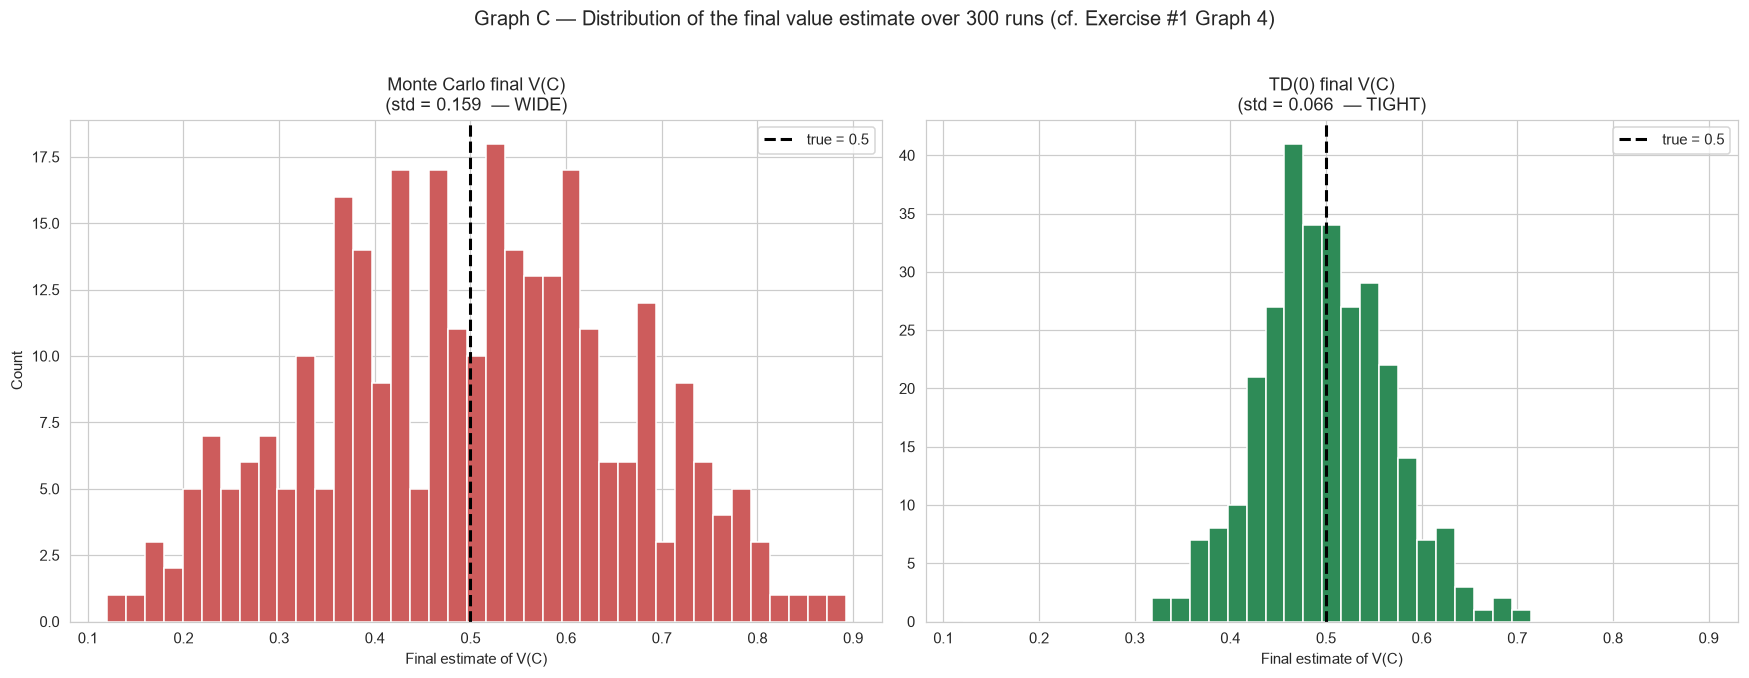

In [8]:
N_REPEATS = 300
BUDGET = 100

final_td = np.empty(N_REPEATS)
final_mc = np.empty(N_REPEATS)
for r in range(N_REPEATS):
    Vtd, _ = td0_prediction(BUDGET, alpha=0.10, seed=20_000 + r)
    Vmc, _ = mc_prediction(BUDGET, alpha=0.04, seed=20_000 + r)
    final_td[r] = Vtd[START_STATE]
    final_mc[r] = Vmc[START_STATE]

print(f"After {BUDGET} episodes, across {N_REPEATS} runs (true V(C) = 0.5):")
print(f"  TD(0):  mean={final_td.mean():.3f}  std={final_td.std():.3f}  "
      f"min={final_td.min():.3f}  max={final_td.max():.3f}")
print(f"  MC   :  mean={final_mc.mean():.3f}  std={final_mc.std():.3f}  "
      f"min={final_mc.min():.3f}  max={final_mc.max():.3f}")

lo = min(final_td.min(), final_mc.min())
hi = max(final_td.max(), final_mc.max())
bins = np.linspace(lo, hi, 40)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
ax[0].hist(final_mc, bins=bins, color='indianred', edgecolor='white')
ax[0].axvline(0.5, color='black', ls='--', lw=2, label='true = 0.5')
ax[0].set_title(f'Monte Carlo final V(C)\n(std = {final_mc.std():.3f}  — WIDE)')
ax[0].set_xlabel('Final estimate of V(C)'); ax[0].set_ylabel('Count'); ax[0].legend()

ax[1].hist(final_td, bins=bins, color='seagreen', edgecolor='white')
ax[1].axvline(0.5, color='black', ls='--', lw=2, label='true = 0.5')
ax[1].set_title(f'TD(0) final V(C)\n(std = {final_td.std():.3f}  — TIGHT)')
ax[1].set_xlabel('Final estimate of V(C)'); ax[1].legend()

plt.suptitle('Graph C — Distribution of the final value estimate over 300 runs (cf. Exercise #1 Graph 4)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**What do we see here?**

- **MC (left):** a **wide** distribution of final answers — pick one run and you could be noticeably off.
- **TD (right):** a **tighter** spike on 0.5 — any single run is more trustworthy.
- Compare this to Exercise #1's Graph 4, where *ordinary importance sampling* gave the wide smear and *weighted IS* the tight spike. **Same lesson, new method:** TD's bootstrapped target plays the variance-taming role that weighted IS played for off-policy MC.

### Graph D — Variance vs episodes: TD stays lower the whole way

Finally, we track the **variance of the `V(C)` estimate across 200 runs** as the episode budget grows. Both should shrink — but TD should sit **below** MC throughout.

budget=   1:  Var(TD)=0.00000   Var(MC)=0.00462
budget=   5:  Var(TD)=0.00003   Var(MC)=0.01551
budget=  10:  Var(TD)=0.00035   Var(MC)=0.01849
budget=  25:  Var(TD)=0.00235   Var(MC)=0.02054
budget=  50:  Var(TD)=0.00360   Var(MC)=0.02360
budget= 100:  Var(TD)=0.00423   Var(MC)=0.01969
budget= 200:  Var(TD)=0.00407   Var(MC)=0.02041


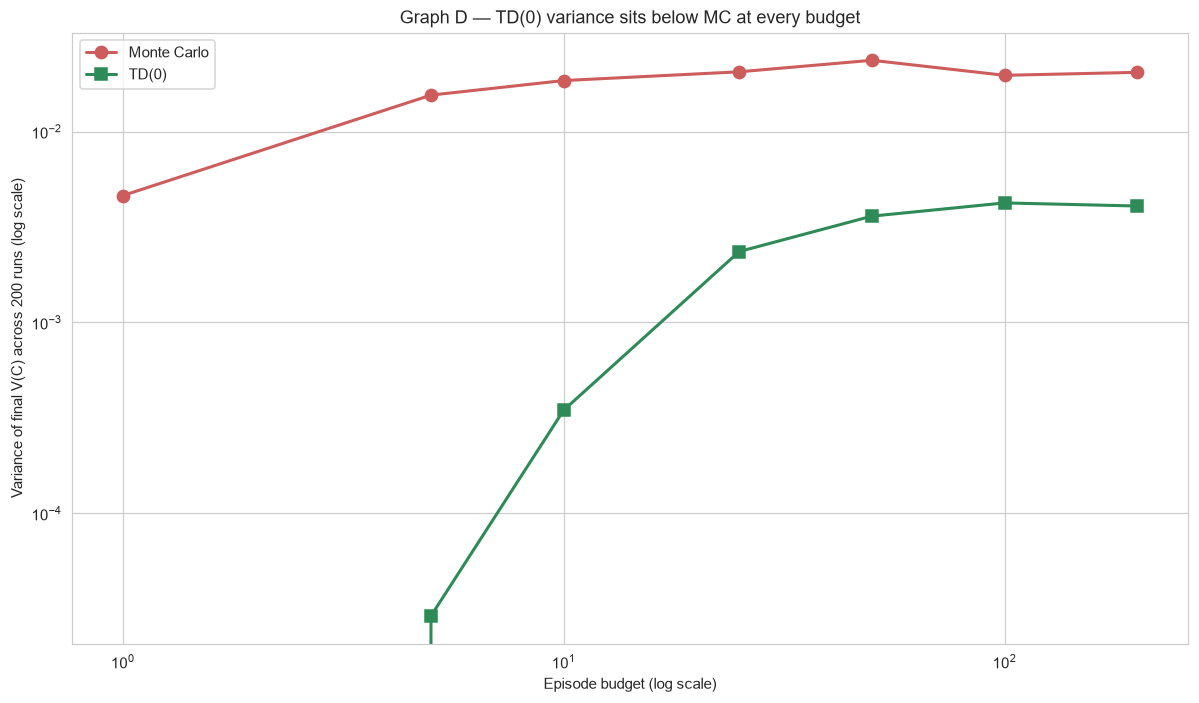

In [9]:
budgets = [1, 5, 10, 25, 50, 100, 200]
N_RUNS_VAR = 200

var_td, var_mc = [], []
for budget in budgets:
    td_vals, mc_vals = [], []
    for r in range(N_RUNS_VAR):
        Vtd, _ = td0_prediction(budget, alpha=0.10, seed=30_000 + r)
        Vmc, _ = mc_prediction(budget, alpha=0.04, seed=30_000 + r)
        td_vals.append(Vtd[START_STATE])
        mc_vals.append(Vmc[START_STATE])
    var_td.append(np.var(td_vals))
    var_mc.append(np.var(mc_vals))
    print(f"budget={budget:>4}:  Var(TD)={np.var(td_vals):.5f}   Var(MC)={np.var(mc_vals):.5f}")

plt.figure(figsize=(11, 6.5))
plt.plot(budgets, var_mc, 'o-', color='indianred', lw=2, ms=8, label='Monte Carlo')
plt.plot(budgets, var_td, 's-', color='seagreen', lw=2, ms=8, label='TD(0)')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Episode budget (log scale)')
plt.ylabel('Variance of final V(C) across 200 runs (log scale)')
plt.title('Graph D — TD(0) variance sits below MC at every budget')
plt.legend()
plt.tight_layout()
plt.show()

**Key Insight — the clincher:**

- Both curves fall as we add episodes (unlike Exercise #1's *ordinary IS*, whose variance refused to shrink at all).
- But **TD(0) sits below MC at every budget** — for the same number of episodes, TD gives you a more reliable number.
- This is the quantitative version of "TD mitigates MC's variance," and the direct contrast with Exercise #1's never-shrinking variance curve.

### Graph E — Mean estimate with a variance band, against the true mean

Graph D answered *"how big is the spread?"* but its y-axis is **variance** (units of value²), so the true mean `v_π(C) = 0.5` has no place on it — variance is measured *around* the center, so the center cancels out.

Here we switch the y-axis back to the **value estimate itself**. That single change lets all three ideas share one chart: the **center line** is the mean estimate of `V(C)` across 200 runs, the **shaded band** is ±1 std (the variance, now drawn as a *ribbon width*), and the **dashed line** is the true mean 0.5. Same data as Graph D — read differently.

budget=   1:  TD mean=0.500 ±0.000   MC mean=0.498 ±0.067
budget=   5:  TD mean=0.500 ±0.006   MC mean=0.492 ±0.127
budget=  10:  TD mean=0.501 ±0.020   MC mean=0.512 ±0.162
budget=  25:  TD mean=0.498 ±0.049   MC mean=0.481 ±0.146
budget=  50:  TD mean=0.494 ±0.066   MC mean=0.486 ±0.155
budget= 100:  TD mean=0.493 ±0.071   MC mean=0.504 ±0.154
budget= 200:  TD mean=0.501 ±0.074   MC mean=0.520 ±0.156


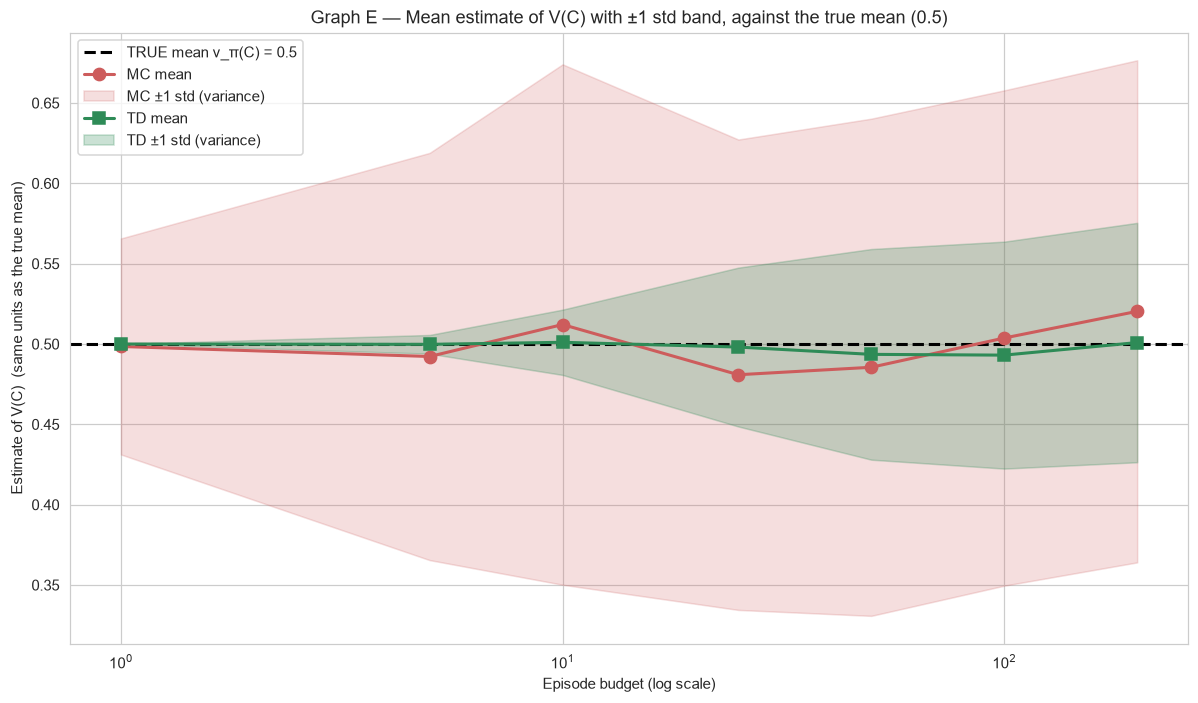

In [10]:
budgets = [1, 5, 10, 25, 50, 100, 200]
N_RUNS = 200

# For each budget, collect the final V(C) over many runs, then summarise as mean ± std.
mean_td, std_td, mean_mc, std_mc = [], [], [], []
for budget in budgets:
    td_vals, mc_vals = [], []
    for r in range(N_RUNS):
        Vtd, _ = td0_prediction(budget, alpha=0.10, seed=40_000 + r)
        Vmc, _ = mc_prediction(budget, alpha=0.04, seed=40_000 + r)
        td_vals.append(Vtd[START_STATE])
        mc_vals.append(Vmc[START_STATE])
    mean_td.append(np.mean(td_vals)); std_td.append(np.std(td_vals))
    mean_mc.append(np.mean(mc_vals)); std_mc.append(np.std(mc_vals))
    print(f"budget={budget:>4}:  TD mean={np.mean(td_vals):.3f} ±{np.std(td_vals):.3f}   "
          f"MC mean={np.mean(mc_vals):.3f} ±{np.std(mc_vals):.3f}")

mean_td, std_td = np.array(mean_td), np.array(std_td)
mean_mc, std_mc = np.array(mean_mc), np.array(std_mc)

plt.figure(figsize=(11, 6.5))
# The true mean can be drawn HERE because the y-axis is value, not variance.
plt.axhline(0.5, color='black', ls='--', lw=2, label='TRUE mean v_π(C) = 0.5')

plt.plot(budgets, mean_mc, 'o-', color='indianred', lw=2, ms=8, label='MC mean')
plt.fill_between(budgets, mean_mc - std_mc, mean_mc + std_mc,
                 color='indianred', alpha=0.20, label='MC ±1 std (variance)')

plt.plot(budgets, mean_td, 's-', color='seagreen', lw=2, ms=8, label='TD mean')
plt.fill_between(budgets, mean_td - std_td, mean_td + std_td,
                 color='seagreen', alpha=0.25, label='TD ±1 std (variance)')

plt.xscale('log')
plt.xlabel('Episode budget (log scale)')
plt.ylabel('Estimate of V(C)  (same units as the true mean)')
plt.title('Graph E — Mean estimate of V(C) with ±1 std band, against the true mean (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

**Key Insight — variance and the true mean, finally on one chart:**

- The **dashed black line** is the true mean `v_π(C) = 0.5`. It can live here (but *not* on Graph D) because this y-axis is the **value estimate itself**, not variance — same units as the true value.
- The **band width** carries exactly the message of Graph D — the spread of the estimate — and the **green TD band stays narrower than the red MC band at every budget**. Lower variance, drawn as a thinner ribbon.
- The **center lines** add what a pure-variance plot can't show: the *mean* converging onto 0.5. Watch TD's center start a touch **below** 0.5 at tiny budgets — that's its early bootstrapping **bias** — then close the gap. So this single graph shows all three at once: **bias** (center vs dashed line), **variance** (band width), and **convergence** (both shrinking toward the bullseye).

---
# Part 5 — The Honest Trade-off: Bias vs Variance

TD's lower variance isn't a free lunch. There's a catch worth saying out loud.

| | **Monte Carlo** | **TD(0)** |
|---|---|---|
| Target | Full return `G` (fully sampled) | `R + γV(S')` (part estimate = **bootstrapped**) |
| **Bias** | **Unbiased** — `G` is a true sample of the return | **Biased early** — leans on `V(S')`, which is wrong at first |
| **Variance** | **High** — soaks up the whole episode's randomness | **Low** — one step of randomness per update |
| Learns | Only at episode end | At **every step** (works for non-terminating tasks too) |
| Needs | Complete episodes | Just the next step |

> **The mirror image of Exercise #1.** There, *weighted importance sampling* accepted a little **bias** to crush the **variance** of off-policy MC. Here, *TD(0)* accepts a little **bias** (from bootstrapping off imperfect estimates) to crush the **variance** of MC. Same trade, different costume. In practice the trade is almost always worth it — which is why TD is the engine inside Q-learning, SARSA, and modern deep RL.

**What surprised us?** TD reaches a *lower* error than MC *even though MC is the unbiased one* (Graph B). Intuition says "unbiased should win," but with a fixed episode budget MC's enormous variance hurts it more than TD's small bias hurts TD. Low-variance-but-slightly-biased beats unbiased-but-wild — exactly the moral of Exercise #1.

---
# Part 6 — Conclusion & Reflection

### Summary of what we built

| Deliverable (from the exercise) | Where | Result |
|---|---|---|
| Study the **TD(0)** pseudocode | Part 1–2 | Translated line-by-line into Python |
| **Produce Python to run it** | Parts 2–3 | TD(0) converges to true random-walk values `1/6…5/6` |
| **Stubs showing it mitigates MC's variance** | Part 4 | Four graphs: target distribution, RMS curves, value distribution, variance-vs-N |
| Be ready to present | whole notebook | Traces + graphs you can talk through from the IDE |

### Key Takeaways

1. **Bootstrapping is the whole idea.** TD updates an estimate using another estimate (`R + γV(S')`) instead of waiting for the true return. This lets it learn every step *and* slashes variance, because each update absorbs only one step of randomness.

2. **Variance mitigation is real and measurable.** Graph A shows the mechanism (a 0/1 coin-flip target vs a tight wobble); Graphs B–D show the payoff (faster learning, tighter final-estimate distribution, lower variance at every budget).

3. **It's a bias–variance trade, not magic.** TD is *biased* early because it trusts imperfect neighbour estimates. But on a fixed budget that small bias costs far less than MC's large variance — so TD wins.

4. **This is the same story as Exercise #1, told from the other side.** Off-policy MC + ordinary IS = unbiased but variance-exploding. Weighted IS and TD(0) are two different ways of accepting a pinch of bias to buy a mountain of stability.

### What trade-offs were made?

- **Bias vs variance** — discussed above; the heart of the exercise.
- **Constant-α MC vs first-visit MC** — we used constant-α every-visit MC so the *only* difference from TD is the target (fair comparison), at the cost of not showing MC's unbiased-in-the-limit behaviour.
- **Simple world vs realism** — the 5-state random walk has *known* true values, which is exactly what lets us *measure* variance. A richer environment would hide the effect behind noise.

### Limitations (honest)

- TD(0)'s bias means that with a *very* large budget, unbiased MC can eventually match or edge it on some tasks — our fixed-budget story favours TD.
- The random walk is undiscounted and episodic; the bias picture changes with `γ < 1` and with bootstrapping over many steps (n-step TD, TD(λ)).
- We only did **prediction** (evaluating a fixed π), matching the slide title `v_π`. Control (finding the best policy) adds its own wrinkles — next topics.

### What could be improved / next steps

- **n-step TD and TD(λ)** dial smoothly between TD(0) and MC — tune exactly how much bootstrapping (variance ↓) vs sampling (bias ↓) you want.
- **Batch TD vs batch MC** to show they converge to *different* answers (TD finds the maximum-likelihood MDP estimate — the certainty-equivalence solution).
- Move from prediction to **control**: SARSA (on-policy TD control) and **Q-learning** (off-policy TD control), which combine today's variance-taming with Exercise #1's off-policy power.

### The big picture

Exercise #1 showed us the danger: importance-sampling variance that can blow up to infinity. Exercise #2 shows the cure that powers modern RL — **bootstrapping**. By leaning on its own current estimate instead of waiting for the full, noisy return, TD(0) turns a wild estimator into a steady one. That single trick, accepting a little bias for a lot of stability, is the beating heart of Q-learning, SARSA, and the deep-RL agents that play games and drive cars today.